Name: S. ASWIN
Roll No: 24BAD014
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture

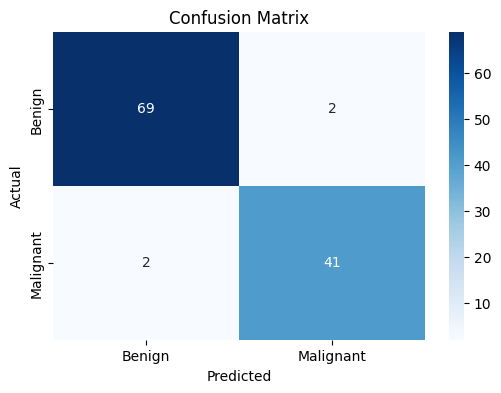

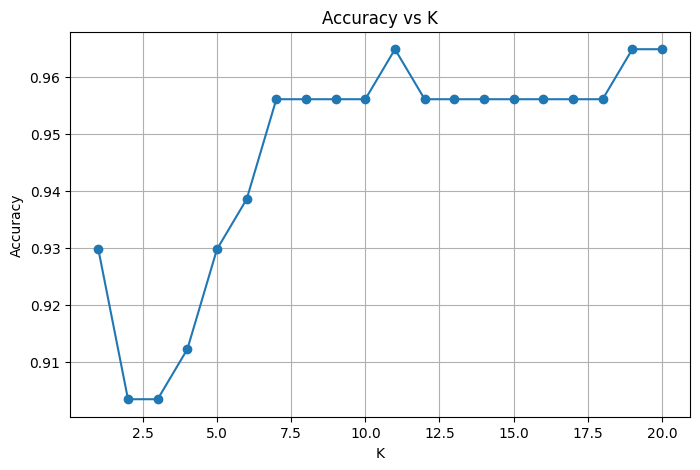

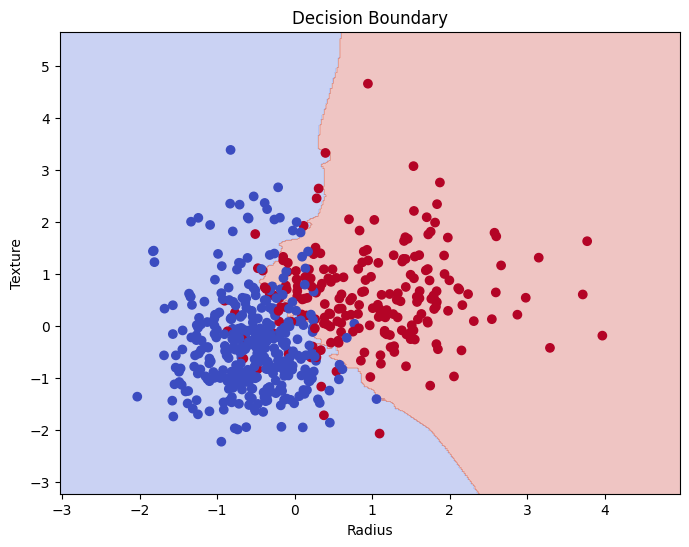

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Name: S. ASWIN")
print("Roll No: 24BAD014")

df = pd.read_csv("breast-cancer.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())

features = ['radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean']
X = df[features]
y = df['diagnosis']

le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)

best_k = k_values[np.argmax(accuracy_scores)]
print("Best K:", best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

misclassified = np.where(y_test != y_pred)
print("Misclassified:", misclassified)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=["Benign","Malignant"],
            yticklabels=["Benign","Malignant"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy_scores, marker='o')
plt.title("Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

X_vis = df[['radius_mean','texture_mean']].values
y_vis = le.fit_transform(df['diagnosis'])

X_vis = scaler.fit_transform(X_vis)

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vis, y_vis, test_size=0.2, random_state=42
)

knn_vis = KNeighborsClassifier(n_neighbors=best_k)
knn_vis.fit(X_train_v, y_train_v)

x_min, x_max = X_vis[:,0].min() - 1, X_vis[:,0].max() + 1
y_min, y_max = X_vis[:,1].min() - 1, X_vis[:,1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

plt.scatter(X_vis[:,0], X_vis[:,1], c=y_vis, cmap=plt.cm.coolwarm)
plt.xlabel("Radius")
plt.ylabel("Texture")
plt.title("Decision Boundary")
plt.show()

Name: S. ASWIN
Roll No: 24BAD014
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural  

/tmp/ipykernel_250/1420988940.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
/tmp/ipykernel_250/1420988940.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

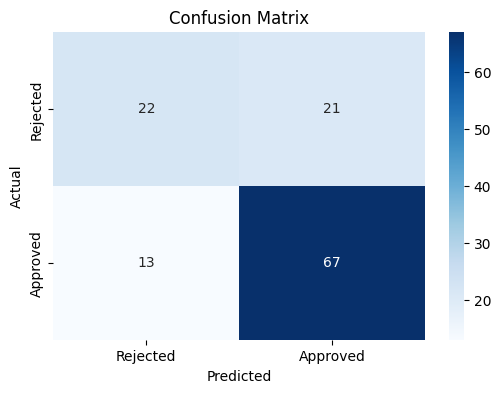

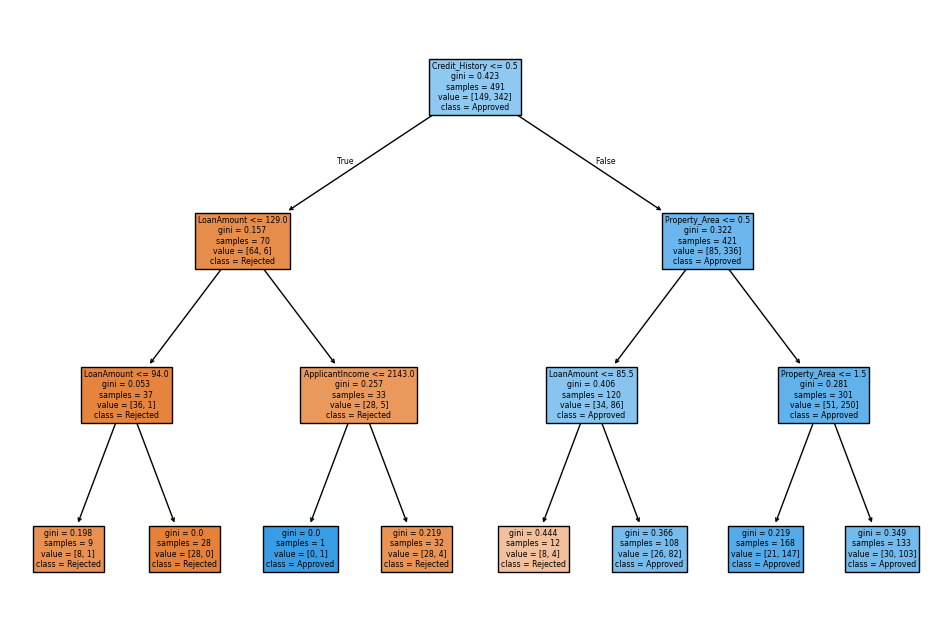

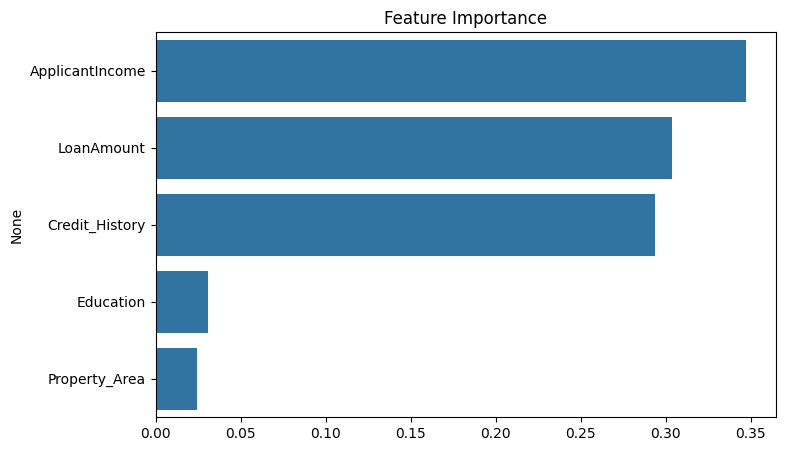

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Name: S. ASWIN")
print("Roll No: 24BAD014")

df = pd.read_csv("/content/train_u6lujuX_CVtuZ9i (1).csv")

print(df.head())
print(df.isnull().sum())

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['Education'].fillna(df['Education'].mode()[0], inplace=True)
df['Property_Area'].fillna(df['Property_Area'].mode()[0], inplace=True)

features = ['ApplicantIncome','LoanAmount','Credit_History','Education','Property_Area']
X = df[features]
y = df['Loan_Status']

le = LabelEncoder()

X['Education'] = le.fit_transform(X['Education'])
X['Property_Area'] = le.fit_transform(X['Property_Area'])
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_shallow.fit(X_train, y_train)

dt_deep = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_deep.fit(X_train, y_train)

y_pred_shallow = dt_shallow.predict(X_test)
y_pred_deep = dt_deep.predict(X_test)

print("Shallow Tree Accuracy:", accuracy_score(y_test, y_pred_shallow))
print("Deep Tree Accuracy:", accuracy_score(y_test, y_pred_deep))

print(classification_report(y_test, y_pred_deep))

cm = confusion_matrix(y_test, y_pred_deep)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=["Rejected","Approved"],
            yticklabels=["Rejected","Approved"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12,8))
plot_tree(dt_shallow, feature_names=X.columns, class_names=["Rejected","Approved"], filled=True)
plt.show()

importance = dt_deep.feature_importances_

plt.figure(figsize=(8,5))
sns.barplot(x=importance, y=X.columns)
plt.title("Feature Importance")
plt.show()